# Tesla Deliveries Forecasting Using Machine Learning

## Objective

The objective of this project is to predict Tesla vehicle deliveries using historical production, pricing, battery specifications, charging infrastructure, and regional information.

## Workflow

1. Data Preprocessing
2. Exploratory Data Analysis (EDA)
3. Feature Engineering
4. Linear Regression
5. Random Forest Regression
6. Hyperparameter Tuning
7. Model Comparison
8. Conclusion

## Import Libraries

In [1]:
# Import libraries for data manipulation, visualization,
# machine learning, and time series forecasting
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import GridSearchCV

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from statsmodels.tsa.holtwinters import ExponentialSmoothing

import warnings
warnings.filterwarnings("ignore")

In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv


## Load Dataset

In [3]:
# Load the Tesla deliveries dataset into a pandas DataFrame
df = pd.read_csv('/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv')

# Display the first few rows to understand the dataset structure
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [4]:
# Understand the dataset structure, data types, and dimensions
print("Shape:", df.shape)

df.info()

Shape: (2640, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


## Statistical Summary

In [5]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


## Check Missing Values

In [6]:
# Check for missing values in each column
df.isnull().sum()

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

## Check Duplicate Records

In [7]:
print("Duplicate Rows:", df.duplicated().sum())


Duplicate Rows: 0


## Remove Duplicates

In [8]:
df = df.drop_duplicates()

print(df.shape)

(2640, 12)


## Distribution of Deliveries

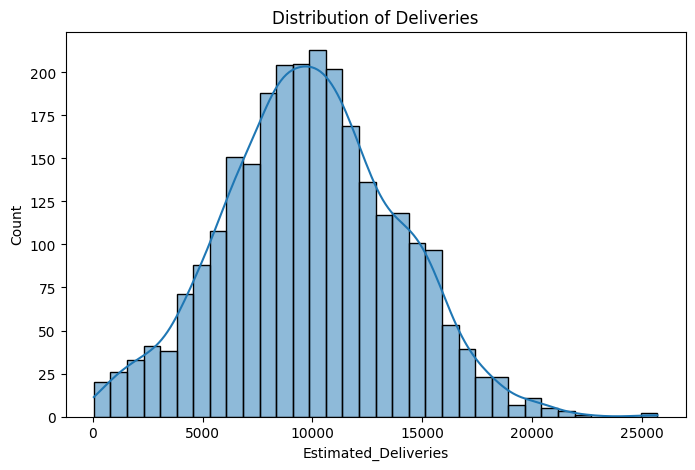

In [9]:
# Visualize the distribution of vehicle deliveries
# to understand data spread and skewness
plt.figure(figsize=(8,5))

sns.histplot(
    df["Estimated_Deliveries"],
    kde=True
)

plt.title("Distribution of Deliveries")
plt.show()

## Correlation Heatmap

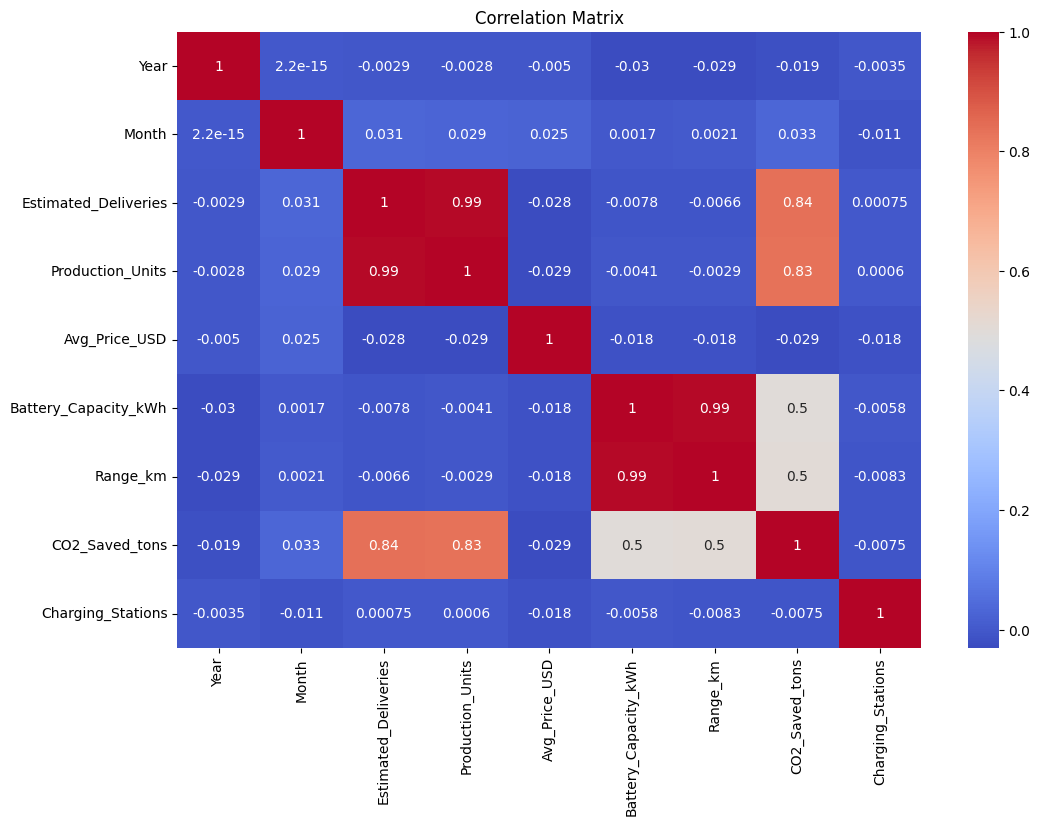

In [10]:
# Analyze relationships between numerical features
# using a correlation matrix
plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

## Deliveries by Region

###### Compare total deliveries across different regions
region_sales = df.groupby("Region")["Estimated_Deliveries"].sum()

region_sales.sort_values().plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Deliveries by Region")
plt.show()

## Deliveries by Model

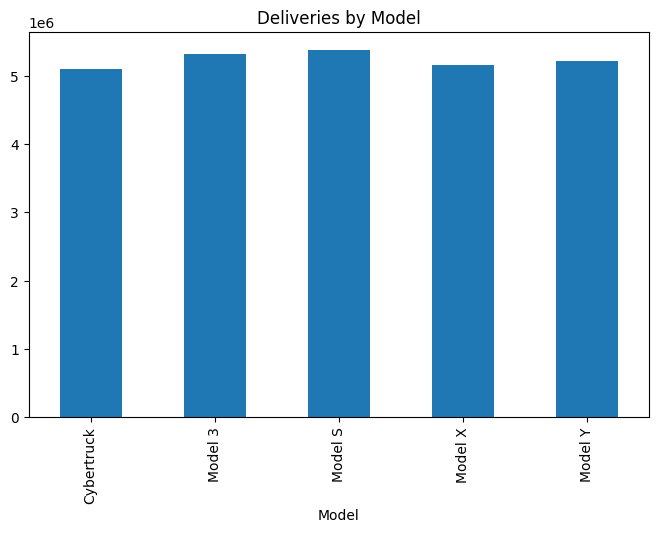

In [12]:
# Identify which Tesla models contribute most to deliveries
model_sales = df.groupby("Model")["Estimated_Deliveries"].sum()

model_sales.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Deliveries by Model")
plt.show()

## Create Date Feature

In [13]:
# Combine Year and Month into a datetime column
df["Date"] = pd.to_datetime(
    dict(
        year=df["Year"],
        month=df["Month"],
        day=1
    )
)

df[["Year","Month","Date"]].head()

,Year,Month,Date
0,2023,5,2023-05-01
1,2015,2,2015-02-01
2,2019,1,2019-01-01
3,2021,2,2021-02-01
4,2016,12,2016-12-01


## Feature Engineering

Delivery Efficiency

In [14]:
# Create a new feature representing the ratio of
# deliveries to production units
df["Delivery_Efficiency"] = (
    df["Estimated_Deliveries"] /
    df["Production_Units"]
)

In [15]:
# Price Per KM
df["Price_per_KM"] = (
    df["Avg_Price_USD"] /
    df["Range_km"]
)

In [16]:
# Check Features
df[[
    "Delivery_Efficiency",
    "Price_per_KM"
]].head()

,Delivery_Efficiency,Price_per_KM
0,0.984600,131.923679
1,0.911864,142.022032
2,0.915334,245.598583
3,0.896594,125.414199
4,0.914087,173.747020


In [17]:
# Define Features and Target
X = df.drop(
    ["Estimated_Deliveries","Date"],
    axis=1
)

y = df["Estimated_Deliveries"]

In [18]:
# Identify Column Types
numerical_cols = X.select_dtypes(
    exclude="object"
).columns

categorical_cols = X.select_dtypes(
    include="object"
).columns

print(numerical_cols)
print(categorical_cols)

Index(['Year', 'Month', 'Production_Units', 'Avg_Price_USD',
       'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons',
       'Charging_Stations', 'Delivery_Efficiency', 'Price_per_KM'],
      dtype='object')
Index(['Region', 'Model', 'Source_Type'], dtype='object')


 ## Build Preprocessing Pipeline

In [19]:
# Handle missing values and encode categorical variables
numeric_transformer = Pipeline(
[
("imputer",
 SimpleImputer(strategy="median"))
]
)

categorical_transformer = Pipeline(
[
("encoder",
 OneHotEncoder(handle_unknown="ignore"))
]
)

preprocessor = ColumnTransformer(
[
("num",
 numeric_transformer,
 numerical_cols),

("cat",
 categorical_transformer,
 categorical_cols)
]
)

## Train Test Split

In [20]:
## Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Linear Regression

In [21]:
# Linear Regression Pipeline
lr_pipeline = Pipeline(
[
("preprocessor", preprocessor),
("model", LinearRegression())
]
)

lr_pipeline.fit(X_train,y_train)

lr_pred = lr_pipeline.predict(X_test)

## Evaluate Linear Regression

In [22]:
# Evaluate model performance using
# MAE, RMSE, and R² Score
print("MAE:",
      mean_absolute_error(y_test, lr_pred))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test, lr_pred)))

print("R2:",
      r2_score(y_test, lr_pred))

MAE: 108.94025141910805
RMSE: 153.61603680646817
R2: 0.9984169173068257


## Random Forest Pipeline

In [23]:
rf_pipeline = Pipeline(
[
("preprocessor", preprocessor),
("model",
 RandomForestRegressor(
     random_state=42
 ))
]
)

rf_pipeline.fit(X_train,y_train)

rf_pred = rf_pipeline.predict(X_test)

## Evaluate Random Forest

In [24]:
print("MAE:",
      mean_absolute_error(y_test, rf_pred))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test, rf_pred)))

print("R2:",
      r2_score(y_test, rf_pred))

MAE: 67.22710227272728
RMSE: 108.524589657905
R2: 0.9992098913924995


## Hyperparameter Tuning

In [25]:
# Define parameter grid for Random Forest optimization
param_grid = {

"model__n_estimators":[100,200],

"model__max_depth":[
    5,
    10,
    None
],

"model__min_samples_split":[
    2,
    5
]
}

In [26]:
# Use GridSearchCV to find the best model parameters
grid_search = GridSearchCV(

rf_pipeline,

param_grid,

cv=5,

scoring="r2",

n_jobs=-1
)

grid_search.fit(X_train,y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median'))]),
                                                                         Index(['Year', 'Month', 'Production_Units', 'Avg_Price_USD',
       'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons',
       'Charging_Stations', 'Delivery_Efficiency', 'Price_per_KM'],
      dtype='object')),
                                                                        ('cat',
                                                                         Pipeline(steps=[('encoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         Index(['Region', 'Model', 'Source_Type'], dtype='object'))])),
                                       ('model',
                                        RandomForestRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [5, 10, None],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [100, 200]},
             scoring='r2')

## Best Parameters

In [27]:
# Display the optimal hyperparameter combination
print(grid_search.best_params_)

print(grid_search.best_score_)

{'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 200}
0.9982960700489427


## Feature Importance

In [28]:
# Identify features that have the greatest impact
# on delivery prediction
best_model = grid_search.best_estimator_

feature_names = (
best_model.named_steps["preprocessor"]
.get_feature_names_out()
)

importances = (
best_model.named_steps["model"]
.feature_importances_
)

importance_df = pd.DataFrame({
    "Feature":feature_names,
    "Importance":importances
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

importance_df.head(10)

,Feature,Importance
2,num__Production_Units,0.990461
8,num__Delivery_Efficiency,0.008635
6,num__CO2_Saved_tons,0.000243
1,num__Month,0.000104
9,num__Price_per_KM,0.000090
7,num__Charging_Stations,0.000079
3,num__Avg_Price_USD,0.000079
0,num__Year,0.000074
5,num__Range_km,0.000072
21,cat__Source_Type_Official (Quarter),0.000031


## Visualize Feature Importance

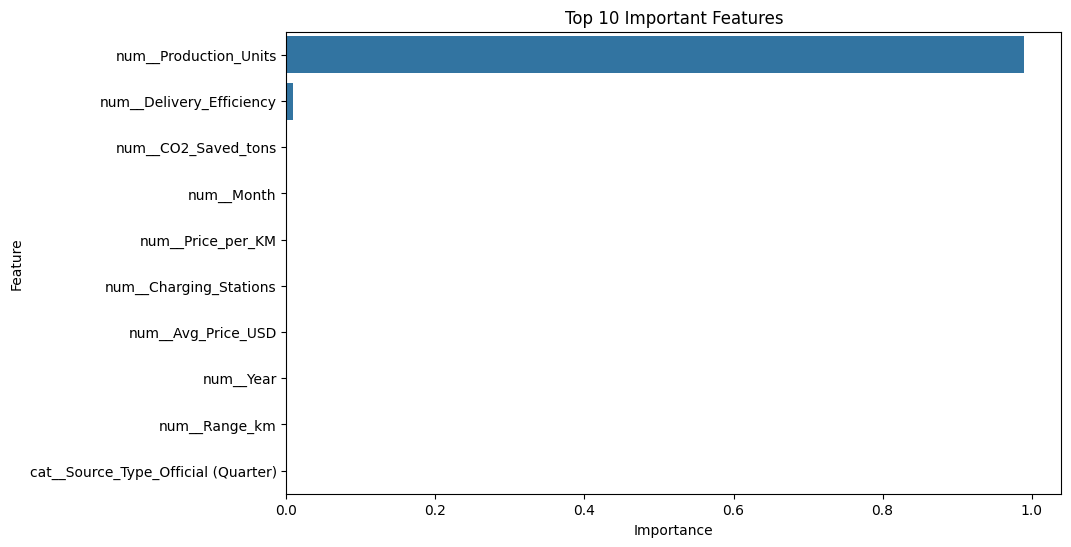

In [29]:
# Visualize the top 10 most important features
top_features = importance_df.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=top_features
)

plt.title("Top 10 Important Features")

plt.show()

## Time Series Preparation 

In [30]:
## Aggregate monthly deliveries for forecasting 
monthly_sales = df.groupby(
    "Date"
)["Estimated_Deliveries"].sum()

monthly_sales.head()

Date
2015-01-01    183180
2015-02-01    165053
2015-03-01    184567
2015-04-01    225623
2015-05-01    184264
Name: Estimated_Deliveries, dtype: int64

## Plot Historical Trend

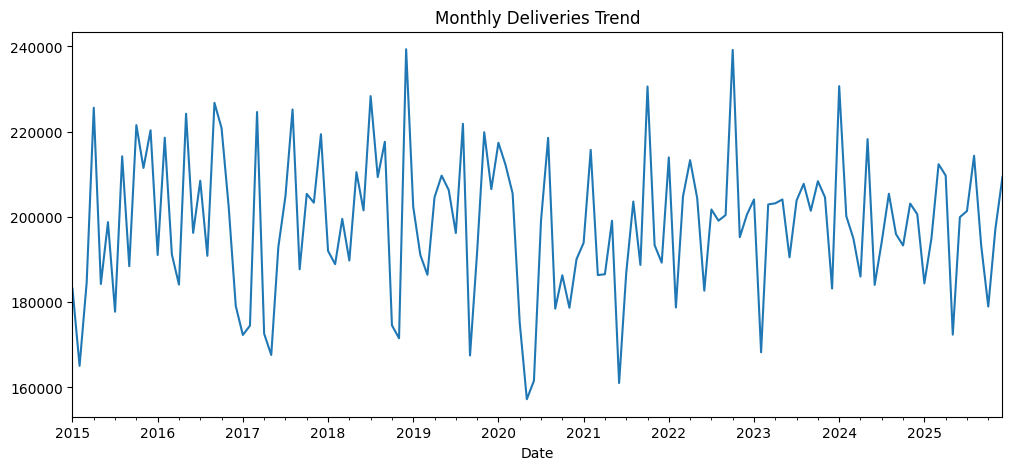

In [31]:
# Plot historical delivery trends over time
plt.figure(figsize=(12,5))

monthly_sales.plot()

plt.title("Monthly Deliveries Trend")

plt.show()

## Time Series Forecasting

In [32]:
forecast_model = ExponentialSmoothing(
    monthly_sales,
    trend="add",
    seasonal="add",
    seasonal_periods=12
)

fit_model = forecast_model.fit()

In [33]:
## Forecast Next 12 Months
forecast = fit_model.forecast(12)

forecast

2026-01-01    192503.413088
2026-02-01    190435.129208
2026-03-01    198070.502476
2026-04-01    189794.124276
2026-05-01    197737.023790
2026-06-01    192220.156886
2026-07-01    201206.012233
2026-08-01    208206.054814
2026-09-01    198374.685638
2026-10-01    203016.972600
2026-11-01    195870.464575
2026-12-01    206739.087753
Freq: MS, dtype: float64

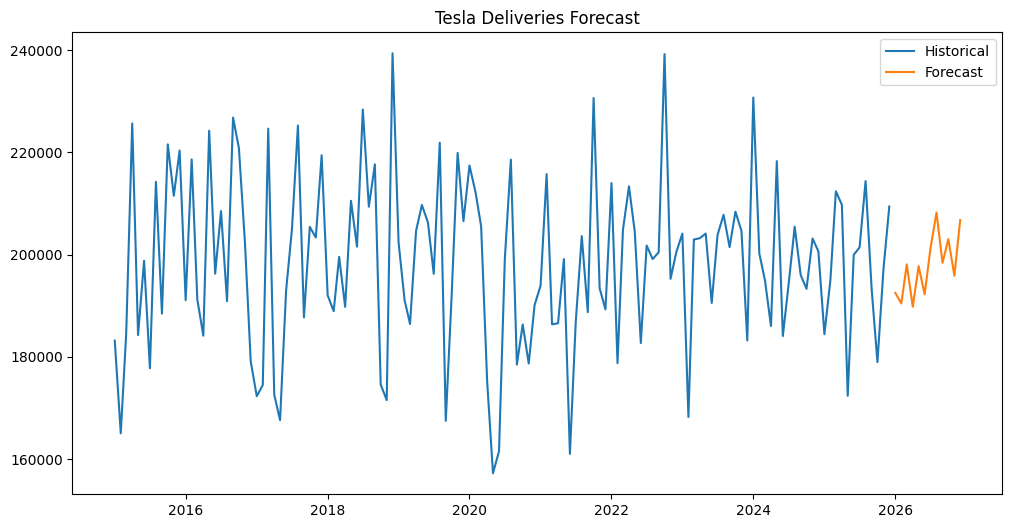

In [34]:
## Plot Forecast
plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales,
    label="Historical"
)

plt.plot(
    forecast,
    label="Forecast"
)

plt.legend()

plt.title("Tesla Deliveries Forecast")

plt.show()

# Conclusion 
- Performed data cleaning, preprocessing, and exploratory data analysis (EDA) to understand Tesla delivery trends and key influencing factors.
- Created new features and built Machine Learning models to predict vehicle deliveries, comparing Linear Regression and Random Forest Regression.
- Applied GridSearchCV for hyperparameter tuning and identified the most important features affecting delivery performance.
- Used a time series forecasting model (Holt-Winters) to predict future deliveries, completing an end-to-end ML pipeline.